# Arbre de décision  - Modèle de classification

In [ ]:
# pour faire des modèles statistiques ( sa forme abrégée pour l'appeler comme une fonction)
import statsmodels as stat
# https://seaborn.pydata.org Seaborn is a Python data visualization library based on matplotlib.
# It provides a high-level interface for drawing attractive and informative statistical graphics.
import seaborn as sbrn
# pour implementer des fonctions R
import pandas as pd
# pour mettre en place des graphiques / pyplot c 'est le module dédié
import matplotlib.pyplot as plt
# c 'est pour les traitements  de facon generale
import numpy as np


from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler



#  Objectif : on étude le comportement d'achat d utilisateur
data = pd.read_csv("social.csv")

In [80]:
data.head()

,Identifiant_d_utilisateur,Le_genre,Age,EstimationSalaire,Achete
0,109371570,Homme,19,266000,0
1,110676608,Homme,35,280000,0
2,109680025,Femme,26,602000,0
3,109222722,Femme,27,798000,0
4,110628014,Homme,19,1064000,0


In [81]:
data.describe()

,Identifiant_d_utilisateur,Age,EstimationSalaire,Achete
count,4.000000e+02,400.000000,4.000000e+02,400.000000
mean,1.098408e+08,37.655000,9.763950e+05,0.357500
std,5.016083e+05,10.482877,4.773574e+05,0.479864
min,1.089668e+08,18.000000,2.100000e+05,0.000000
25%,1.093873e+08,29.750000,6.020000e+05,0.000000
50%,1.098604e+08,37.000000,9.800000e+05,0.000000
75%,1.102525e+08,46.000000,1.232000e+06,1.000000
max,1.107067e+08,60.000000,2.100000e+06,1.000000


In [82]:
# on garde que l'age et l'estimation de salaire.
x = data.iloc[:,-3:-1].values
#print (data.iloc[:,-3:-1])
# pour le y achete ou pas
y = data.iloc[:,-1].values
#print(data.iloc[:,-1])

In [83]:
# découper les datasets ( training et test)
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state= 0)

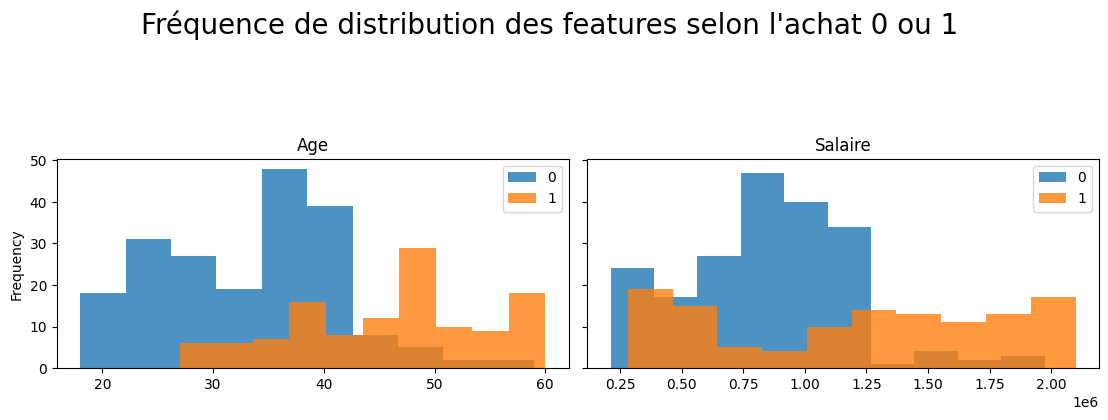

,Age,Salaire
count,320.00000,3.200000e+02
mean,38.21875,9.789938e+05
std,10.30304,4.839808e+05
min,18.00000,2.100000e+05
25%,30.00000,6.020000e+05
50%,38.00000,9.730000e+05
75%,46.00000,1.232000e+06
max,60.00000,2.100000e+06


In [84]:
#exploration statistique des features AVANT SCALING
# d 'abord on transforme x_train en dataframe pour simplifier l usage des fonction de plot
x_train_df = pd.DataFrame(x_train,columns=['Age','Salaire'])
y_train_df = pd.DataFrame(y_train, columns=['Achete'])

# LA fonction concat combine dans le dataframe les objets horizentalement (axe x), ceci  est vrai quand on met axis 1
df = pd.concat([x_train_df,y_train_df],axis=1)

# Notice x-axis on subplots are all the same for all features (0 to 1) after scaling.
fig = plt.figure(figsize=(12,7))
fig.suptitle('Fréquence de distribution des features selon l\'achat 0 ou 1 ' ,fontsize=20)

ax1 = fig.add_subplot(221)
# ici on groupe en fonction des labels qu'on va prédire dans la colonne achete ( le y)
df.groupby("Achete").Age.plot(kind='hist',alpha=0.8,legend=True,title='Age')
ax2 = fig.add_subplot(222,sharey=ax1)
df.groupby("Achete").Salaire.plot(kind='hist',alpha=0.8,legend=True,title='Salaire')
plt.tight_layout(pad=4, w_pad=1, h_pad=1.5)
plt.show()
# résumé statistique des features
x_train_df.describe()

In [85]:
#Scaling ( mise à l'échelle )
# Le standardScaler normalise les variables de sorte qu'elles aient une moyenne nulle et une variance égale à 1
# ( ainsi que l'écart type ) . Pour une variable cela correspond à retrancer à chaque observation la moyenne de la
# variable. Ce procédé est appelé "centrage-réduction"
SC = StandardScaler()
x_train = SC.fit_transform(x_train)
x_test = SC.transform(x_test)

In [86]:
# Scaling on peut également utiliser MinMaxScaler par exemple
# Ce module normalise les vraibles pour qu'elles évoluent entre 0 et 1 ( xstd = ( x-min(x) / ( max(x) - min(x))))
MMS = MinMaxScaler()
x_train = MMS.fit_transform(x_train)

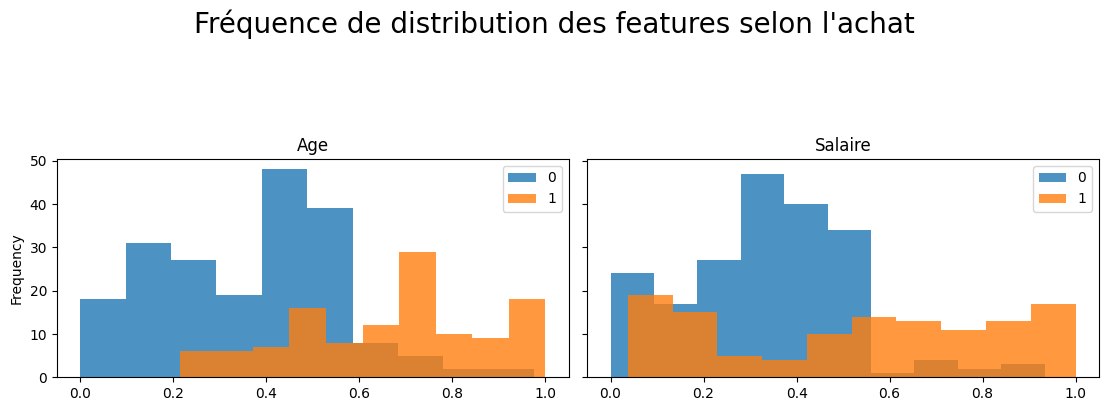

,Age,Salaire
count,320.000000,320.000000
mean,0.481399,0.406875
std,0.245310,0.256074
min,0.000000,0.000000
25%,0.285714,0.207407
50%,0.476190,0.403704
75%,0.666667,0.540741
max,1.000000,1.000000


In [87]:
#exploration statistique des features
# d 'abord on transforme x_train en dataframe pour simplifier l usage des fonction de plot
x_train_sc_df = pd.DataFrame(x_train,columns=['Age','Salaire'])
y_train_sc_df = pd.DataFrame(y_train, columns=['Achete'])

# LA fonction concat combine dans le dataframe les objets horizentalement (axe x), ceci  est vrai quand on met axis 1
df_sc = pd.concat([x_train_sc_df,y_train_sc_df],axis=1)

# Notice x-axis on subplots are all the same for all features (0 to 1) after scaling.
fig = plt.figure(figsize=(12,7))
fig.suptitle('Fréquence de distribution des features selon l\'achat' ,fontsize=20)

ax1 = fig.add_subplot(221)
df_sc.groupby("Achete").Age.plot(kind='hist',alpha=0.8,legend=True,title='Age')
ax2 = fig.add_subplot(222,sharey=ax1)
df_sc.groupby("Achete").Salaire.plot(kind='hist',alpha=0.8,legend=True,title='Salaire')

plt.tight_layout(pad=4, w_pad=1, h_pad=1.5)
plt.show()
x_train_sc_df.describe()
# on constate qu'il est moins évident d'interpréter quand on passe le scaling sur les dataset

In [88]:
# construction de l 'arbre de décision
# l'entrepy
# ICI on utilise  un modèle de classfication
from sklearn.tree import DecisionTreeClassifier
classDecAr = DecisionTreeClassifier(criterion ='entropy' , random_state= 0)
# avec une profondeur de 5 , regardons après le modèle généré.
#classDecAr = DecisionTreeClassifier(criterion ='entropy' , random_state= 0, max_depth=5)
classDecAr.fit(x_train, y_train)
# le modèle est construit

DecisionTreeClassifier(criterion='entropy', random_state=0)

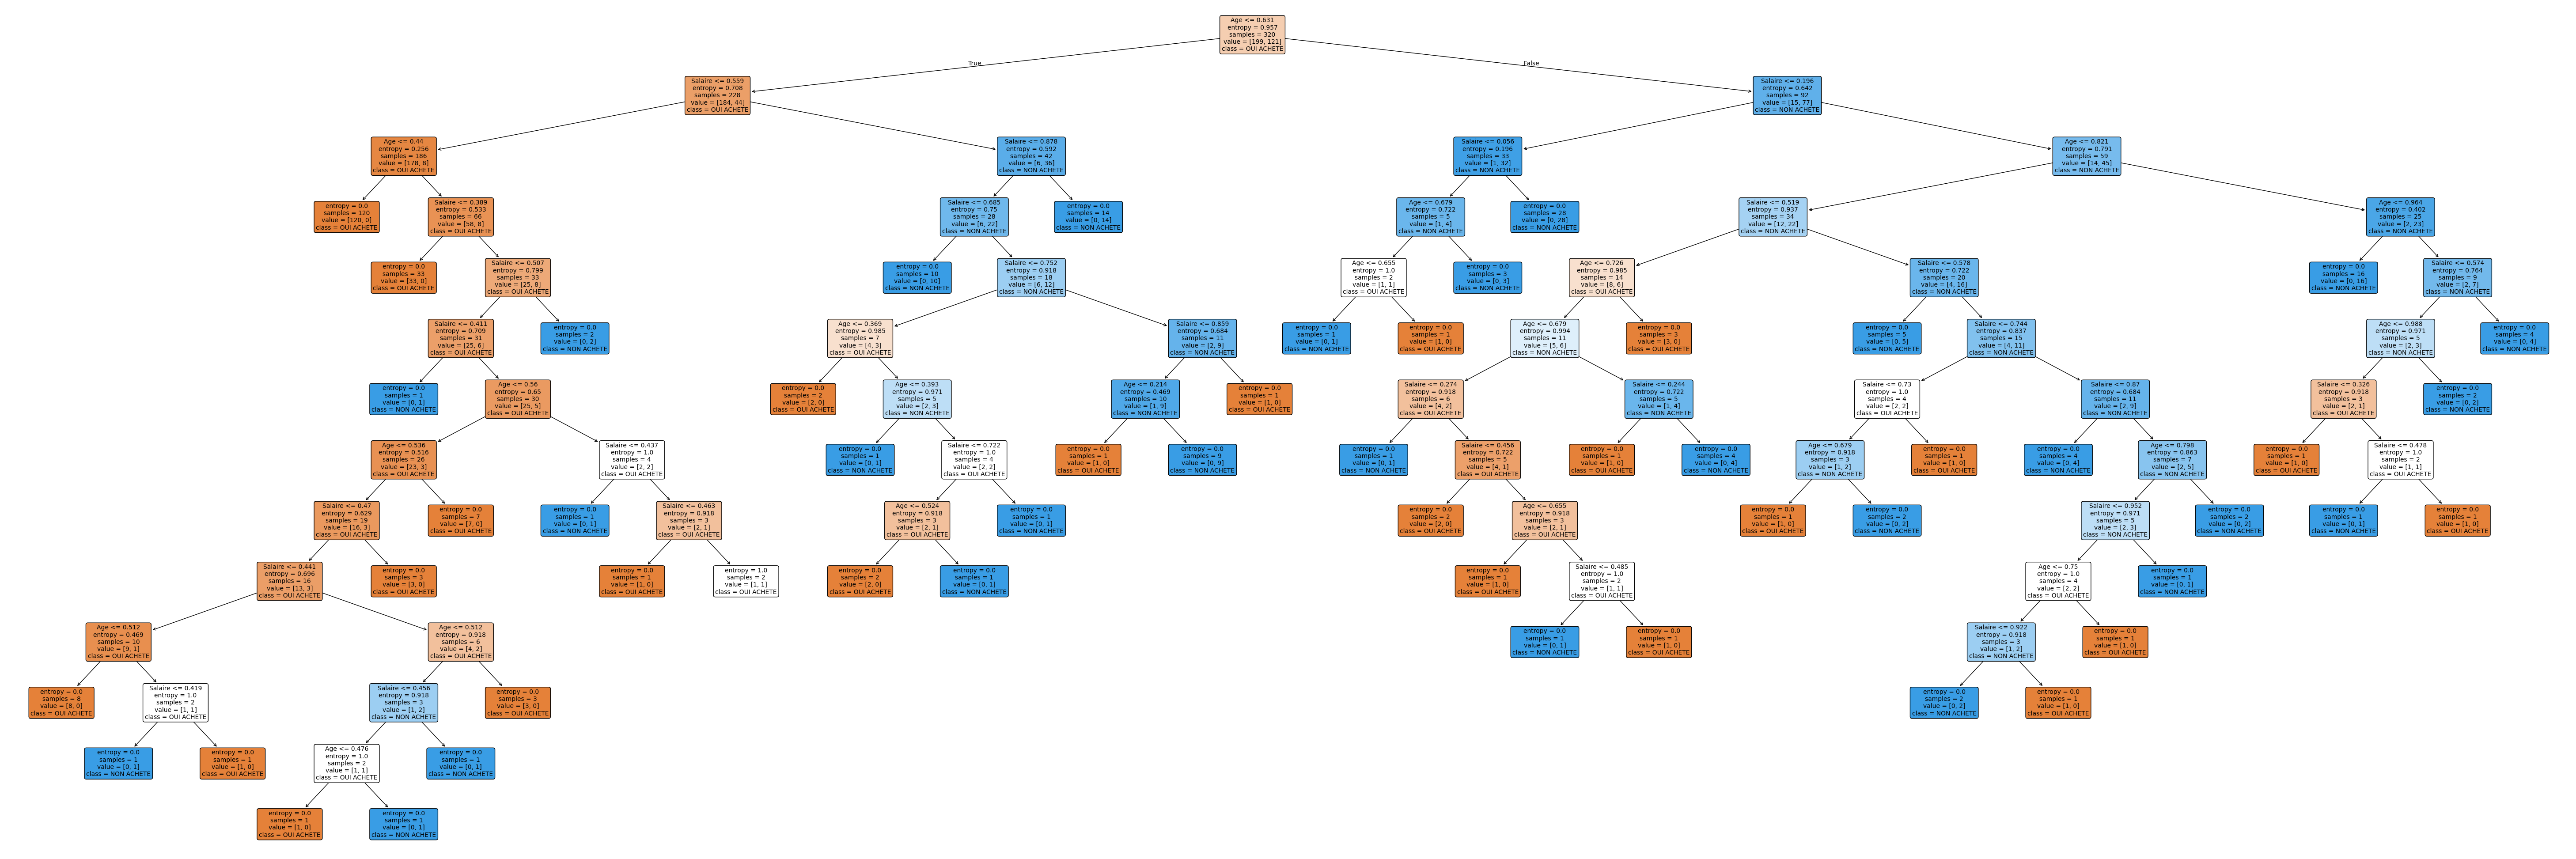

In [89]:
plt.figure(figsize=(75,25))
plot_tree(classDecAr, 
          feature_names=x_train_df.columns, 
          class_names=['OUI ACHETE','NON ACHETE'], 
          filled=True,        # color nodes by class
          rounded=True,       # rounded boxes
          fontsize=10)
plt.show()

Commentons la méthode DecisionTreeClassifier

D'abord il faut savoir que nous avons plusieurs implémentations d'arbre de décision : ID3, C4.5, C5.0 et CART
scikit-learn utilise une version optimisée de l'algoritme CART.

voir section 10.6 dans ce lien officiel de scikit-learn  http://scikit-learn.org/stable/modules/tree.html


L'explication des différents paramètres se trouve dans ce lien
http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

Criterion : il peut être "entropy" (mesurant le gain d'informaiton) ou "gini" ( the Gini impurity).
Cette FONCTION SERT A MESURER LA QUALITE DU SPLIT LORS DE LA CONSTRUCTION DE L ARBRE DE DECISION

-----------------------------------------
L'entropy c 'est une mesure qui sert à evaluer le désordre
****** "Entropy is a measure of disorder / Entropy is an indicator of how messy your data is." :
    c 'est à dire plus on s 'approche de 0 notre échantillon est homogène --> impureté faible
    plus on s'approche de 1 on est sur un échantillon équitablement réparti --> impureté forte
En arbre de décision l'entropy nous permettra de séparer les échantillon de groupe dans des classes le plus possible homogène (on maximise la pureté)

Reférons nous à ce lien pour comprendre avec un exemple comment on clacule l'entropy
https://www.saedsayad.com/decision_tree.htm
# très sympa aussi comme lien à voir ( vous!) https://bricaud.github.io/personal-blog/entropy-in-decision-trees/

****** indice de Gini : pareil c 'est une mesure de désordre

![gini.png](attachment:gini.png)

In [90]:
# faire la prédiction sur le x_test
y_pred = classDecAr.predict(x_test)

Rappelons la matrice de confusion et les mesures d'évaluation de modèle
![confusion.png](attachment:confusion.png)

Accuracy = (VP + VN ) / ( VP+ VN + FP + FN ) ( autrement dit c 'est la justesse de modèle )

Recall = ( VP) / ( VP + FN )

Precision = (VP) /( VP + FP)

F1-score = 2 * (precision * recall) / (precision + recall)

In [91]:
# mettre en place une matrice de confusion pour évaluer le modèle et le valider
from sklearn.metrics import confusion_matrix

In [92]:
mat_conf = confusion_matrix(y_test, y_pred)

In [93]:
print(mat_conf)

[[55  3]
 [ 4 18]]


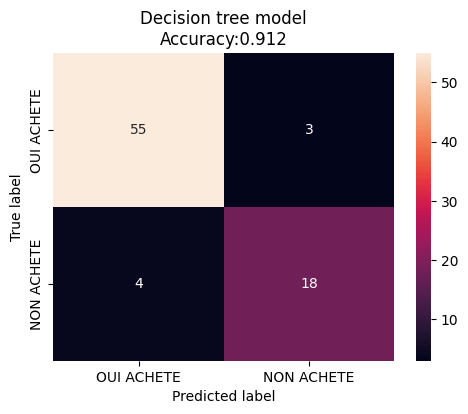

In [94]:
#plus sympa pour la visualisation de la matrice de confusion

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, precision_recall_fscore_support
import seaborn  as sbrn
# pour mettre en place des graphiques / pyplot c 'est le module dédiée
import matplotlib.pyplot as mtpl

# on crée la matrice de confusion
mat_conf = confusion_matrix(y_test, y_pred)

# on transforme cette matrice de confusion en data frame
mat_conf_df = pd.DataFrame(mat_conf,
                     index = ['OUI ACHETE','NON ACHETE'],
                     columns = ['OUI ACHETE','NON ACHETE'])

mtpl.figure(figsize=(5.5,4))
sbrn.heatmap(mat_conf_df, annot=True)
mtpl.title('Decision tree model\nAccuracy:{0:.3f}'.format(accuracy_score(y_test, y_pred)))
mtpl.ylabel('True label')
mtpl.xlabel('Predicted label')
mtpl.show()

In [95]:
print('precision score is ', precision_score(y_test, y_pred))
print('recall score is ', recall_score(y_test, y_pred))
print('f1-measure is ', f1_score(y_test, y_pred))

precision score is  0.8571428571428571
recall score is  0.8181818181818182
f1-measure is  0.8372093023255814


C:\Temp\ipykernel_6736\1145635665.py:18: UserWarning: The following kwargs were not used by contour: 'mat_confap'
  mtpl.contourf(x1,x2, classDecAr.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
C:\Temp\ipykernel_6736\1145635665.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  mtpl.scatter(x_set[y_set == j , 0], x_set[y_set == j , 1],


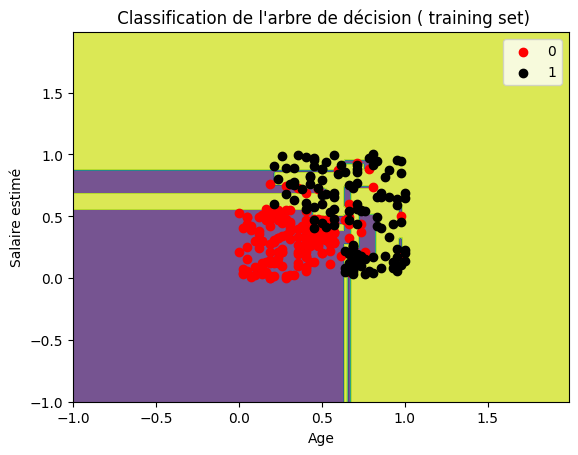

In [96]:
# Pour visualiser les résultats prédits par rapport à ceux

from matplotlib.colors import ListedColormap
import matplotlib.pyplot as mtpl

# on crée deux ensembles à partir de x_train et y_train
x_set,y_set = x_train, y_train

# on utilise la fonction meshgrid de numpy qui retourne lles coordonnées d'une matrice
# à partir des coordonnées de vecteurs
# X1 c 'est l age
# X2 c'est le salaire
# np.arange --> ca permet de faire un rangement de valeur
x1 , x2 = np.meshgrid( np.arange(start=x_set[:,0].min()-1, stop=x_set[:,0].max() + 1, step= 0.01),
                       np.arange(start=x_set[:,1].min()-1, stop=x_set[:,1].max() + 1, step= 0.01))

# On fait les contours avec matplotf
mtpl.contourf(x1,x2, classDecAr.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
              alpha= 0.75, mat_confap = ListedColormap(('red', 'green')))
mtpl.xlim(x1.min(), x1.max())
mtpl.ylim(x2.min(), x2.max())
for i, j  in enumerate(np.unique(y_test)):
    mtpl.scatter(x_set[y_set == j , 0], x_set[y_set == j , 1],
                c = ListedColormap(('red', 'black'))(i), label= j)
mtpl.title(' Classification de l\'arbre de décision ( training set)')
mtpl.xlabel('Age')
mtpl.ylabel('Salaire estimé')
mtpl.legend()
mtpl.show()